# Bloc 2 — Prototype Retrieval sur ViDoRe
## Questions 7 & 8 — Analyse Différentielle & Stratégie Hybride
### Étude de cas NOVAGEN Biopharma | RAG Agentique Multimodal

**VDR par défaut : ColQwen2.5-v0.2** (late interaction, MaxSim)  
Comparaisons : Textuel (BioBERT) · CLIP (dense cosine) · ColQwen2.5 (MaxSim) · Hybrides RRF/WSF


---
## 0. Imports & Configuration

In [1]:
import warnings, os, gc, io, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
from collections import defaultdict
from pathlib import Path
from datasets import load_dataset
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
from PIL import Image

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

BASE_DIR = Path(".")

# ── Textual embeddings (BioBERT) ──────────────────────────────────────────────
TEXT_CORPUS_EMB   = BASE_DIR / "embeddings_textual_corpus.json"
TEXT_QUERY_EMB    = BASE_DIR / "embeddings_textual_queries.json"

# ── CLIP visual embeddings (dense cosine baseline) ────────────────────────────
CLIP_CORPUS_EMB   = BASE_DIR / "embeddings_visual_corpus.json"
CLIP_QUERY_EMB    = BASE_DIR / "embeddings_visual_queries.json"

# ── ColQwen2.5 late-interaction caches (from Q6) ──────────────────────────────
COLQWEN_CORPUS_PT = BASE_DIR / "colqwen_corpus_embeddings.pt"
COLQWEN_QUERY_PT  = BASE_DIR / "colqwen_query_embeddings.pt"

print("Checking files :")
for label, p in [
    ("BioBERT corpus",   TEXT_CORPUS_EMB),
    ("BioBERT queries",  TEXT_QUERY_EMB),
    ("CLIP corpus",      CLIP_CORPUS_EMB),
    ("CLIP queries",     CLIP_QUERY_EMB),
    ("ColQwen corpus",   COLQWEN_CORPUS_PT),
    ("ColQwen queries",  COLQWEN_QUERY_PT),
]:
    print(f"  {'✓' if p.exists() else '✗'} {label:20s} {p}")


Checking files :
  ✓ BioBERT corpus       embeddings_textual_corpus.json
  ✓ BioBERT queries      embeddings_textual_queries.json
  ✓ CLIP corpus          embeddings_visual_corpus.json
  ✓ CLIP queries         embeddings_visual_queries.json
  ✓ ColQwen corpus       colqwen_corpus_embeddings.pt
  ✓ ColQwen queries      colqwen_query_embeddings.pt


---
## 1. Chargement du dataset ViDoRe V3 Pharmaceuticals

In [2]:
print("Loading ViDoRe v3 pharmaceuticals...")
corpus_ds  = load_dataset("vidore/vidore_v3_pharmaceuticals", "corpus",  split="test")
queries_ds = load_dataset("vidore/vidore_v3_pharmaceuticals", "queries", split="test")
qrels_ds   = load_dataset("vidore/vidore_v3_pharmaceuticals", "qrels",   split="test")

corpus_df  = corpus_ds.to_pandas()
queries_df = queries_ds.to_pandas()
qrels_df   = qrels_ds.to_pandas()

print(f"  corpus : {len(corpus_df)} docs")
print(f"  queries: {len(queries_df)} queries")
print(f"  qrels  : {len(qrels_df)} judgements")
print(f"  qrels columns: {qrels_df.columns.tolist()}")

# ── Detect column names defensively ───────────────────────────────────────────
qid_col   = next(c for c in qrels_df.columns if "query" in c.lower())
did_col   = next(c for c in qrels_df.columns if "corpus" in c.lower() or ("doc" in c.lower() and "query" not in c.lower()))
score_col = next(c for c in qrels_df.columns if "score" in c.lower() or "rel" in c.lower())
q_id_col  = next(c for c in queries_df.columns if "id" in c.lower())
q_txt_col = next(c for c in queries_df.columns if "query" in c.lower() and "id" not in c.lower())
c_id_col  = next(c for c in corpus_df.columns  if "corpus_id" in c.lower() or c.lower() == "id")

qid2text = dict(zip(queries_df[q_id_col].astype(str), queries_df[q_txt_col]))

qrels_dict = defaultdict(dict)   # {query_id_str: {corpus_id_str: relevance}}
for _, row in qrels_df.iterrows():
    qrels_dict[str(row[qid_col])][str(row[did_col])] = float(row[score_col])

print(f"\nQueries with judgements : {len(qrels_dict)}")


Loading ViDoRe v3 pharmaceuticals...
  corpus : 2313 docs
  queries: 2184 queries
  qrels  : 10392 judgements
  qrels columns: ['query_id', 'corpus_id', 'score', 'content_type', 'bounding_boxes']

Queries with judgements : 2184


---
## 2. Chargement des embeddings — BioBERT, CLIP, ColQwen2.5

In [3]:
# ── BioBERT & CLIP (JSON dense embeddings) ────────────────────────────────────
def load_json_emb(path: Path):
    with open(path) as f:
        raw = json.load(f)
    if isinstance(raw, dict):
        ids  = [str(k) for k in raw.keys()]
        embs = np.array([raw[k] for k in raw.keys()], dtype=np.float32)
    elif isinstance(raw, list) and isinstance(raw[0], dict):
        ids  = [str(r["id"]) for r in raw]
        embs = np.array([r["embedding"] for r in raw], dtype=np.float32)
    else:
        raise ValueError(f"Unexpected format in {path}")
    return ids, embs

print("Loading BioBERT embeddings...")
text_corpus_ids,  text_corpus_embs  = load_json_emb(TEXT_CORPUS_EMB)
text_query_ids,   text_query_embs   = load_json_emb(TEXT_QUERY_EMB)
print(f"  BioBERT corpus : {text_corpus_embs.shape}")
print(f"  BioBERT queries: {text_query_embs.shape}")

print("Loading CLIP embeddings...")
clip_corpus_ids,  clip_corpus_embs  = load_json_emb(CLIP_CORPUS_EMB)
clip_query_ids,   clip_query_embs   = load_json_emb(CLIP_QUERY_EMB)
print(f"  CLIP corpus : {clip_corpus_embs.shape}")
print(f"  CLIP queries: {clip_query_embs.shape}")

# ── ColQwen2.5 (.pt tensors, late interaction) ────────────────────────────────
print("\nLoading ColQwen2.5 embeddings from .pt caches...")
cq_corpus_cache  = torch.load(COLQWEN_CORPUS_PT,  map_location='cpu', weights_only=False)
cq_query_cache   = torch.load(COLQWEN_QUERY_PT,   map_location='cpu', weights_only=False)

colqwen_corpus_embs = cq_corpus_cache['embeddings']   # list of Tensors (n_patches, 128)
colqwen_corpus_ids  = [str(cid) for cid in cq_corpus_cache['corpus_ids']]
colqwen_query_embs  = cq_query_cache['embeddings']    # list of Tensors (n_tokens, 128)
colqwen_query_ids   = [str(qid) for qid in cq_query_cache['query_ids']]

print(f"  ColQwen corpus : {len(colqwen_corpus_embs):,} pages | shape ex: {colqwen_corpus_embs[0].shape}")
print(f"  ColQwen queries: {len(colqwen_query_embs):,} queries | shape ex: {colqwen_query_embs[0].shape}")


Loading BioBERT embeddings...
  BioBERT corpus : (2313, 768)
  BioBERT queries: (2184, 768)
Loading CLIP embeddings...
  CLIP corpus : (2313, 512)
  CLIP queries: (2184, 512)

Loading ColQwen2.5 embeddings from .pt caches...
  ColQwen corpus : 2,313 pages | shape ex: torch.Size([731, 128])
  ColQwen queries: 2,184 queries | shape ex: torch.Size([39, 128])


---
## 3. Utilitaires : retrieval & nDCG@5

In [4]:
# ── Dense cosine retrieval (BioBERT / CLIP) ───────────────────────────────────
def retrieve_dense(query_emb: np.ndarray, corpus_embs: np.ndarray,
                   corpus_ids: list, top_k: int = 10):
    sims    = cosine_similarity(query_emb.reshape(1, -1), corpus_embs)[0]
    ranked  = np.argsort(sims)[::-1][:top_k]
    return [(corpus_ids[i], float(sims[i])) for i in ranked]


# ── MaxSim retrieval (ColQwen2.5 late interaction) ────────────────────────────
def maxsim_score(q_emb: torch.Tensor, p_emb: torch.Tensor) -> float:
    q = q_emb.float()
    p = p_emb.float()
    q = q / (q.norm(dim=-1, keepdim=True) + 1e-8)
    p = p / (p.norm(dim=-1, keepdim=True) + 1e-8)
    sim = torch.matmul(q, p.T)                     # (n_tokens, n_patches)
    return sim.max(dim=1).values.sum().item()


def retrieve_colqwen(q_emb: torch.Tensor, corpus_embs: list,
                     corpus_ids: list, top_k: int = 10):
    scores = [(cid, maxsim_score(q_emb, p_emb))
              for cid, p_emb in zip(corpus_ids, corpus_embs)]
    scores.sort(key=lambda x: -x[1])
    return scores[:top_k]


# ── nDCG@5 ────────────────────────────────────────────────────────────────────
def ndcg_at_k(ranked_ids: list, relevant: dict, k: int = 5) -> float:
    dcg, idcg = 0.0, 0.0
    ideal = sorted(relevant.values(), reverse=True)[:k]
    for i, did in enumerate(ranked_ids[:k]):
        rel  = relevant.get(did, 0)
        dcg += (2**rel - 1) / np.log2(i + 2)
    for i, rel in enumerate(ideal):
        idcg += (2**rel - 1) / np.log2(i + 2)
    return dcg / idcg if idcg > 0 else 0.0

print("Utilitaires définis.")


Utilitaires définis.


---
## 4. Index des embeddings et ensemble d'évaluation commun

In [5]:
text_qid2idx    = {qid: i for i, qid in enumerate(text_query_ids)}
clip_qid2idx    = {qid: i for i, qid in enumerate(clip_query_ids)}
colqwen_qid2idx = {qid: i for i, qid in enumerate(colqwen_query_ids)}

# Shared eval set — must exist in ALL three systems AND have qrels
eval_qids = [
    qid for qid in qrels_dict
    if qid in text_qid2idx
    and qid in clip_qid2idx
    and qid in colqwen_qid2idx
]
print(f"Queries disponibles pour évaluation (intersection 3 systèmes) : {len(eval_qids):,}")


Queries disponibles pour évaluation (intersection 3 systèmes) : 2,184


---
## 5. Évaluation individuelle — BioBERT · CLIP · ColQwen2.5

In [6]:
# ColQwen2.5 retrieval cache (expensive — MaxSim O(Q×C))
print("Calcul MaxSim ColQwen2.5 (peut prendre ~40 min sur CPU)...")
print("Note : si colqwen_results_cache.pt existe il sera rechargé.")

COLQWEN_RESULTS_CACHE = BASE_DIR / "colqwen_results_q7q8.pt"

if COLQWEN_RESULTS_CACHE.exists():
    colqwen_results = torch.load(COLQWEN_RESULTS_CACHE, weights_only=False)
    print(f"  Cache chargé : {len(colqwen_results):,} requêtes")
else:
    colqwen_results = {}
    for qid in tqdm(eval_qids, desc="MaxSim ColQwen2.5"):
        idx    = colqwen_qid2idx[qid]
        q_emb  = colqwen_query_embs[idx]
        colqwen_results[qid] = retrieve_colqwen(
            q_emb, colqwen_corpus_embs, colqwen_corpus_ids, top_k=10
        )
    torch.save(colqwen_results, COLQWEN_RESULTS_CACHE)
    print(f"  Cache sauvegardé : {len(colqwen_results):,} requêtes")


Calcul MaxSim ColQwen2.5 (peut prendre ~40 min sur CPU)...
Note : si colqwen_results_cache.pt existe il sera rechargé.


MaxSim ColQwen2.5: 100%|██████████| 2184/2184 [13:17<00:00,  2.74it/s]

  Cache sauvegardé : 2,184 requêtes


In [7]:
results = []   # one dict per query

for qid in tqdm(eval_qids, desc="Evaluating all systems"):
    rel = qrels_dict[qid]

    # ── BioBERT ───────────────────────────────────────────────────────────────
    tq_emb     = text_query_embs[text_qid2idx[qid]]
    text_ret   = retrieve_dense(tq_emb, text_corpus_embs, text_corpus_ids, top_k=10)
    text_ranked = [did for did, _ in text_ret]
    text_ndcg   = ndcg_at_k(text_ranked, rel, k=5)

    # ── CLIP ──────────────────────────────────────────────────────────────────
    cq_emb      = clip_query_embs[clip_qid2idx[qid]]
    clip_ret    = retrieve_dense(cq_emb, clip_corpus_embs, clip_corpus_ids, top_k=10)
    clip_ranked  = [did for did, _ in clip_ret]
    clip_ndcg    = ndcg_at_k(clip_ranked, rel, k=5)

    # ── ColQwen2.5 ────────────────────────────────────────────────────────────
    colqwen_ret     = colqwen_results[qid]
    colqwen_ranked  = [did for did, _ in colqwen_ret]
    colqwen_ndcg    = ndcg_at_k(colqwen_ranked, rel, k=5)

    results.append({
        "query_id":       qid,
        "query_text":     qid2text.get(qid, qid),
        "text_ndcg5":     text_ndcg,
        "clip_ndcg5":     clip_ndcg,
        "colqwen_ndcg5":  colqwen_ndcg,
        "delta_cq_txt":   colqwen_ndcg - text_ndcg,
        "delta_cq_clip":  colqwen_ndcg - clip_ndcg,
        "text_top5":      text_ranked[:5],
        "clip_top5":      clip_ranked[:5],
        "colqwen_top5":   colqwen_ranked[:5],
        "relevant_docs":  list(rel.keys()),
        "text_scores":    dict(text_ret),
        "clip_scores":    dict(clip_ret),
        "colqwen_scores": dict(colqwen_ret),
    })

res_df = pd.DataFrame(results)

print("\n=== nDCG@5 moyen — 3 systèmes ===")
print(f"  Approche A — BioBERT (Textuel) : {res_df['text_ndcg5'].mean():.4f}")
print(f"  Approche B — CLIP   (VDR dense): {res_df['clip_ndcg5'].mean():.4f}")
print(f"  Approche C — ColQwen2.5 (MaxSim): {res_df['colqwen_ndcg5'].mean():.4f}")
print(f"  Delta ColQwen vs BioBERT        : {res_df['delta_cq_txt'].mean():+.4f}")
print(f"  Delta ColQwen vs CLIP           : {res_df['delta_cq_clip'].mean():+.4f}")


Evaluating all systems: 100%|██████████| 2184/2184 [00:17<00:00, 121.96it/s]


=== nDCG@5 moyen — 3 systèmes ===
  Approche A — BioBERT (Textuel) : 0.1032
  Approche B — CLIP   (VDR dense): 0.0929
  Approche C — ColQwen2.5 (MaxSim): 0.5718
  Delta ColQwen vs BioBERT        : +0.4687
  Delta ColQwen vs CLIP           : +0.4789


---
## 6. Comparaison VDR : CLIP (dense) vs ColQwen2.5 (late interaction)

Visualisation de l'apport du late interaction par rapport à l'embedding visuel dense.


ColQwen2.5 > CLIP (Δ>+0.01) : 1,730 requêtes (79.2%)
CLIP > ColQwen2.5 (Δ<-0.01) : 99 requêtes (4.5%)


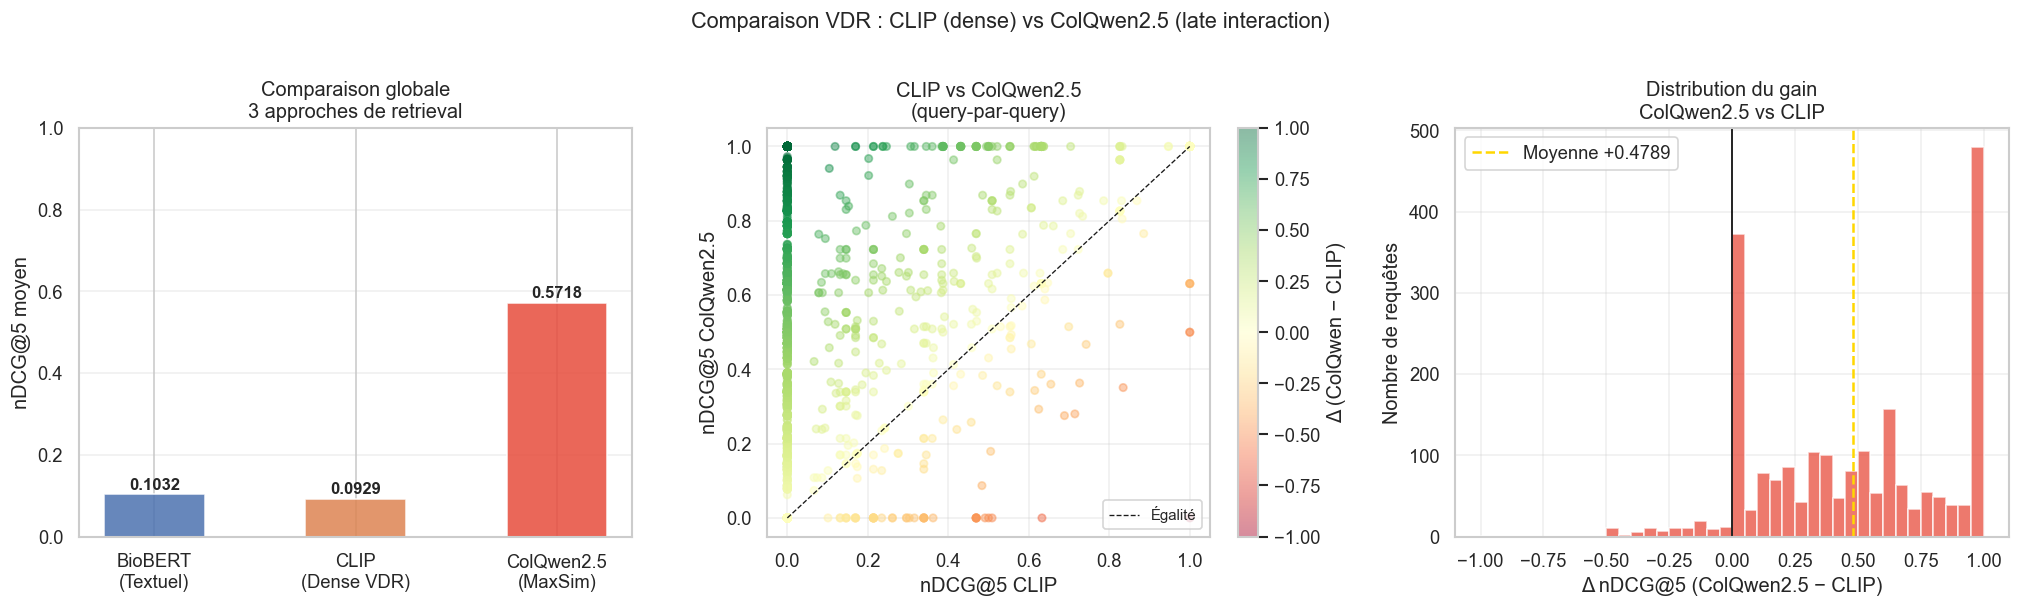

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 6a. Bar chart — 3 approches ───────────────────────────────────────────────
means_3 = {
    "BioBERT\n(Textuel)": res_df['text_ndcg5'].mean(),
    "CLIP\n(Dense VDR)":  res_df['clip_ndcg5'].mean(),
    "ColQwen2.5\n(MaxSim)": res_df['colqwen_ndcg5'].mean(),
}
colors_3 = ["#4C72B0", "#DD8452", "#e74c3c"]
ax = axes[0]
bars = ax.bar(means_3.keys(), means_3.values(), color=colors_3, alpha=0.85, width=0.5)
for bar, val in zip(bars, means_3.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.0)
ax.set_ylabel("nDCG@5 moyen")
ax.set_title("Comparaison globale\n3 approches de retrieval")
ax.grid(axis="y", alpha=0.3)

# ── 6b. Scatter : CLIP vs ColQwen query-level ─────────────────────────────────
ax2 = axes[1]
delta_cq_clip = res_df['delta_cq_clip']
sc = ax2.scatter(res_df['clip_ndcg5'], res_df['colqwen_ndcg5'],
                 c=delta_cq_clip, cmap='RdYlGn', alpha=0.45, s=20, vmin=-1, vmax=1)
plt.colorbar(sc, ax=ax2, label='Δ (ColQwen − CLIP)')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Égalité')
ax2.set_xlabel("nDCG@5 CLIP")
ax2.set_ylabel("nDCG@5 ColQwen2.5")
ax2.set_title("CLIP vs ColQwen2.5\n(query-par-query)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# ── 6c. Delta histogram : ColQwen - CLIP ──────────────────────────────────────
ax3 = axes[2]
ax3.hist(delta_cq_clip, bins=40, color='#e74c3c', alpha=0.75, edgecolor='white')
ax3.axvline(0, color='black', linewidth=1)
ax3.axvline(delta_cq_clip.mean(), color='gold', linewidth=1.5,
            linestyle='--', label=f'Moyenne {delta_cq_clip.mean():+.4f}')
ax3.set_xlabel("Δ nDCG@5 (ColQwen2.5 − CLIP)")
ax3.set_ylabel("Nombre de requêtes")
ax3.set_title("Distribution du gain\nColQwen2.5 vs CLIP")
ax3.legend()
ax3.grid(alpha=0.3)

cq_beats_clip   = (delta_cq_clip > 0.01).sum()
clip_beats_cq   = (delta_cq_clip < -0.01).sum()
print(f"ColQwen2.5 > CLIP (Δ>+0.01) : {cq_beats_clip:,} requêtes ({cq_beats_clip/len(res_df)*100:.1f}%)")
print(f"CLIP > ColQwen2.5 (Δ<-0.01) : {clip_beats_cq:,} requêtes ({clip_beats_cq/len(res_df)*100:.1f}%)")

plt.suptitle("Comparaison VDR : CLIP (dense) vs ColQwen2.5 (late interaction)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## Question 7 — Analyse différentielle : ColQwen2.5 vs BioBERT

Top-20 requêtes les plus divergentes entre le VDR ColQwen2.5 et l'approche textuelle.


In [23]:
# ── Top-10 ColQwen wins + Top-10 BioBERT wins ─────────────────────────────────
cq_top10   = res_df.nlargest(10, "delta_cq_txt").reset_index(drop=True)
text_top10 = res_df.nsmallest(10, "delta_cq_txt").reset_index(drop=True)
top20      = pd.concat([cq_top10, text_top10], ignore_index=True)

print(f"ColQwen2.5 wins — max Δ : {cq_top10['delta_cq_txt'].max():+.4f}  "
      f"min Δ : {cq_top10['delta_cq_txt'].min():+.4f}")
print(f"BioBERT wins   — max Δ : {text_top10['delta_cq_txt'].min():+.4f}  "
      f"min Δ : {text_top10['delta_cq_txt'].max():+.4f}")

print("Top-20 requêtes les plus divergentes (|Δ ColQwen − BioBERT|) :")
display_cols = ["query_id", "query_text", "text_ndcg5", "colqwen_ndcg5", "delta_cq_txt"]
print(top20[display_cols].to_string(index=False))


ColQwen2.5 wins — max Δ : +1.0000  min Δ : +1.0000
BioBERT wins   — max Δ : -1.0000  min Δ : -0.4704
Top-20 requêtes les plus divergentes (|Δ ColQwen − BioBERT|) :
query_id                                                                                                                                                                                               query_text  text_ndcg5  colqwen_ndcg5  delta_cq_txt
       7                                                    Contrast Anne-Emanuelle Birn's critique of structural determinants in public health with a hypothetical proponent of purely biomedical interventions.    0.000000       1.000000      1.000000
      17                                                                     According to FDA guidelines, what is the required format for displaying the strength of a small volume parenteral drug on its label?    0.000000       1.000000      1.000000
      21                                                                         Ho

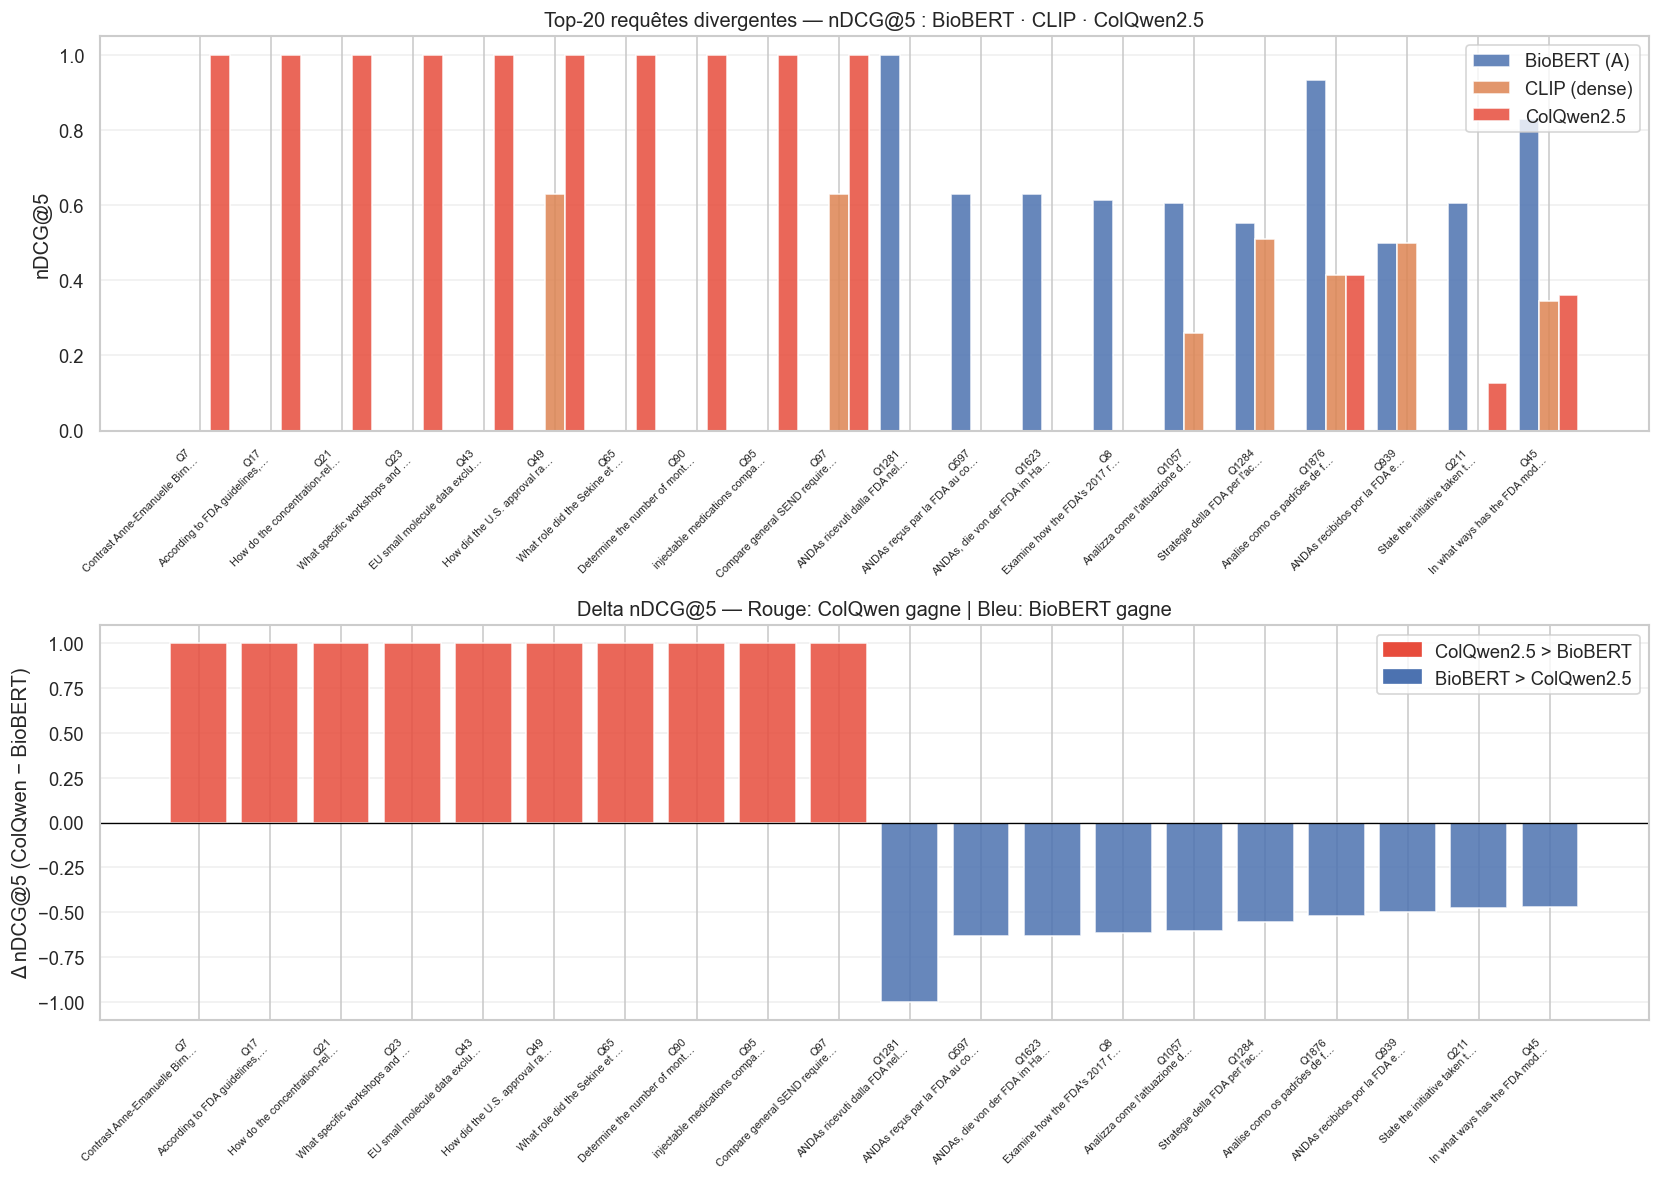

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

x = np.arange(20)
w = 0.28
short_labels = [
    f"Q{row.query_id}\n{row.query_text[:28]}…" if len(row.query_text) > 28
    else f"Q{row.query_id}\n{row.query_text}"
    for _, row in top20.iterrows()
]

ax = axes[0]
ax.bar(x - w, top20["text_ndcg5"],     w, label="BioBERT (A)", color="#4C72B0", alpha=0.85)
ax.bar(x,      top20["clip_ndcg5"],    w, label="CLIP (dense)", color="#DD8452", alpha=0.85)
ax.bar(x + w,  top20["colqwen_ndcg5"], w, label="ColQwen2.5",   color="#e74c3c", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=6.5, rotation=45, ha="right")
ax.set_ylabel("nDCG@5")
ax.set_title("Top-20 requêtes divergentes — nDCG@5 : BioBERT · CLIP · ColQwen2.5")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)

ax2 = axes[1]
colors_bar = ["#e74c3c" if d > 0 else "#4C72B0" for d in top20["delta_cq_txt"]]
ax2.bar(x, top20["delta_cq_txt"], color=colors_bar, alpha=0.85)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(short_labels, fontsize=6.5, rotation=45, ha="right")
ax2.set_ylabel("Δ nDCG@5 (ColQwen − BioBERT)")
ax2.set_title("Delta nDCG@5 — Rouge: ColQwen gagne | Bleu: BioBERT gagne")
ax2.grid(axis="y", alpha=0.3)
patch_c = mpatches.Patch(color="#e74c3c", label="ColQwen2.5 > BioBERT")
patch_t = mpatches.Patch(color="#4C72B0", label="BioBERT > ColQwen2.5")
ax2.legend(handles=[patch_c, patch_t])

plt.tight_layout()
plt.show()


In [25]:
TABLE_KW    = ["table", "tableau", "colonne", "ligne", "valeur",
               "dose", "concentration", "mg", "résultat", "données"]
FIGURE_KW   = ["figure", "graphique", "courbe", "diagramme", "schéma",
               "image", "photo", "illustration", "graph", "chart", "plot"]
LAYOUT_KW   = ["en-tête", "logo", "pied de page", "numéro", "titre",
               "section", "page", "encadré", "mise en page", "colonne"]
NARRATIVE_KW= ["décrit", "explique", "indique", "mentionne", "selon",
               "énonce", "paragraphe", "texte", "passage"]

def categorize(q: str) -> str:
    q = q.lower()
    if any(k in q for k in TABLE_KW):    return "Tableau/Données"
    if any(k in q for k in FIGURE_KW):   return "Figure/Graphique"
    if any(k in q for k in LAYOUT_KW):   return "Structure/Mise en page"
    if any(k in q for k in NARRATIVE_KW):return "Texte narratif"
    return "Autre"

top20["category"] = top20["query_text"].apply(categorize)
top20["winner"]   = top20["delta_cq_txt"].apply(lambda d: "ColQwen2.5" if d > 0 else "BioBERT")

cat_summary = top20.groupby(["category", "winner"]).size().unstack(fill_value=0)
print("\n=== Répartition catégorie × approche gagnante ===")
print(cat_summary)



=== Répartition catégorie × approche gagnante ===
winner           BioBERT  ColQwen2.5
category                            
Autre                  8           8
Tableau/Données        2           2


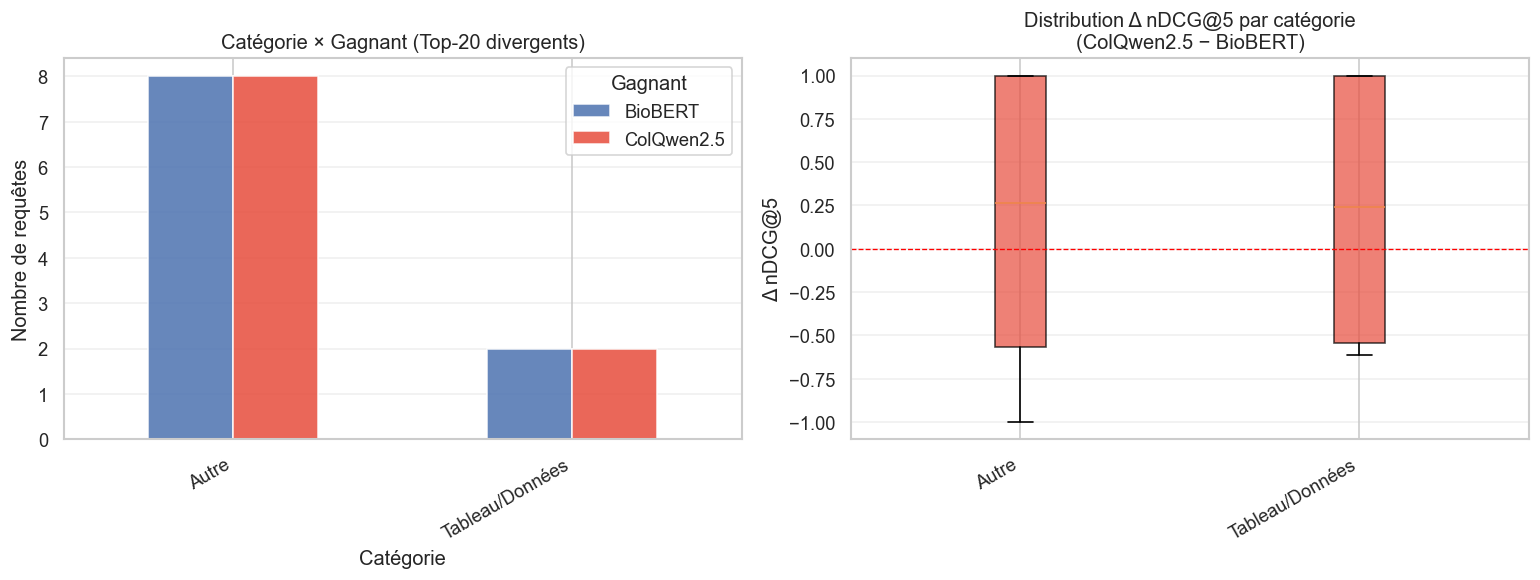

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_summary.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#e74c3c"], alpha=0.85)
axes[0].set_title("Catégorie × Gagnant (Top-20 divergents)")
axes[0].set_xlabel("Catégorie")
axes[0].set_ylabel("Nombre de requêtes")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
axes[0].legend(title="Gagnant")
axes[0].grid(axis="y", alpha=0.3)

cats      = top20["category"].unique()
data_boxes = [top20.loc[top20["category"] == c, "delta_cq_txt"].values for c in cats]
bp = axes[1].boxplot(data_boxes, labels=cats, patch_artist=True)
colors_box = ["#e74c3c" if np.median(d) > 0 else "#4C72B0" for d in data_boxes]
for patch, col in zip(bp["boxes"], colors_box):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[1].set_title("Distribution Δ nDCG@5 par catégorie\n(ColQwen2.5 − BioBERT)")
axes[1].set_ylabel("Δ nDCG@5")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
print("="*70)
print("ANALYSE QUALITATIVE — Top-20 requêtes divergentes")
print("="*70)

cq_wins   = top20[top20["winner"] == "ColQwen2.5"].sort_values("delta_cq_txt", ascending=False)
txt_wins  = top20[top20["winner"] == "BioBERT"].sort_values("delta_cq_txt")

print(f"\n▶ ColQwen2.5 gagne sur {len(cq_wins)} requêtes")
for _, row in cq_wins.head(5).iterrows():
    print(f"  [{row['category']}] QID={row['query_id']} | Δ={row['delta_cq_txt']:+.3f}")
    print(f"    Requête        : {row['query_text']}")
    print(f"    Docs attendus  : {row['relevant_docs']}")
    print(f"    ColQwen top-5  : {row['colqwen_top5']}")
    print(f"    BioBERT top-5  : {row['text_top5']}")
    print()

print(f"▶ BioBERT gagne sur {len(txt_wins)} requêtes")
for _, row in txt_wins.head(5).iterrows():
    print(f"  [{row['category']}] QID={row['query_id']} | Δ={row['delta_cq_txt']:+.3f}")
    print(f"    Requête        : {row['query_text']}")
    print(f"    Docs attendus  : {row['relevant_docs']}")
    print(f"    BioBERT top-5  : {row['text_top5']}")
    print(f"    ColQwen top-5  : {row['colqwen_top5']}")
    print()


ANALYSE QUALITATIVE — Top-20 requêtes divergentes

▶ ColQwen2.5 gagne sur 20 requêtes
  [Autre] QID=7 | Δ=+1.000
    Requête        : Contrast Anne-Emanuelle Birn's critique of structural determinants in public health with a hypothetical proponent of purely biomedical interventions.
    Docs attendus  : ['1549']
    ColQwen top-5  : ['1549', '1558', '1427', '1553', '1587']
    BioBERT top-5  : ['1307', '1496', '1607', '1620', '1426']

  [Autre] QID=17 | Δ=+1.000
    Requête        : According to FDA guidelines, what is the required format for displaying the strength of a small volume parenteral drug on its label?
    Docs attendus  : ['750']
    ColQwen top-5  : ['750', '1905', '745', '749', '746']
    BioBERT top-5  : ['18', '1864', '2038', '2132', '1870']

  [Tableau/Données] QID=21 | Δ=+1.000
    Requête        : How do the concentration-related risks of remdesivir and Propoven 2% differ in medication safety challenges during the pandemic?
    Docs attendus  : ['796']
    ColQwen to

---
## Question 8 — Stratégie Hybride (BioBERT + ColQwen2.5)

Trois fusions sont comparées :
1. **RRF** — Reciprocal Rank Fusion (rang-basé, sans hyperparamètre)
2. **WSF** — Weighted Score Fusion avec sweep α (BioBERT vs ColQwen)

Le VDR utilisé ici est **ColQwen2.5 (MaxSim)**, approche supérieure à CLIP.


In [27]:
def rrf_fusion(ranked_lists: list, k: int = 60) -> list:
    scores = defaultdict(float)
    for ranked in ranked_lists:
        for rank, doc_id in enumerate(ranked):
            scores[doc_id] += 1.0 / (k + rank + 1)
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


def wsf_fusion(text_scores: dict, visual_scores: dict, alpha: float) -> list:
    """alpha * ColQwen + (1-alpha) * BioBERT."""
    combined = {}
    for did in set(text_scores) | set(visual_scores):
        combined[did] = alpha * visual_scores.get(did, 0.0) + (1 - alpha) * text_scores.get(did, 0.0)
    return sorted(combined.items(), key=lambda x: x[1], reverse=True)


alphas = np.arange(0.0, 1.05, 0.05)
wsf_ndcg_by_alpha = defaultdict(list)
rrf_ndcg_list     = []
hybrid_rows       = []

for row in tqdm(results, desc="Hybrid fusion"):
    qid = row["query_id"]
    rel = qrels_dict[qid]

    # RRF (BioBERT + ColQwen)
    rrf_result = rrf_fusion([row["text_top5"], row["colqwen_top5"]])
    rrf_ranked  = [did for did, _ in rrf_result]
    rrf_ndcg    = ndcg_at_k(rrf_ranked, rel, k=5)
    rrf_ndcg_list.append(rrf_ndcg)

    # WSF alpha sweep
    for alpha in alphas:
        wsf_result = wsf_fusion(row["text_scores"], row["colqwen_scores"], alpha)
        wsf_ranked  = [did for did, _ in wsf_result]
        wsf_ndcg    = ndcg_at_k(wsf_ranked, rel, k=5)
        wsf_ndcg_by_alpha[round(alpha, 2)].append(wsf_ndcg)

    hybrid_rows.append({
        "query_id":        qid,
        "text_ndcg5":      row["text_ndcg5"],
        "clip_ndcg5":      row["clip_ndcg5"],
        "colqwen_ndcg5":   row["colqwen_ndcg5"],
        "rrf_ndcg5":       rrf_ndcg,
    })

mean_rrf   = np.mean(rrf_ndcg_list)
wsf_means  = {a: np.mean(v) for a, v in wsf_ndcg_by_alpha.items()}
best_alpha = max(wsf_means, key=wsf_means.get)
best_wsf   = wsf_means[best_alpha]

print("=== nDCG@5 moyen — toutes approches ===")
print(f"  BioBERT (Textuel)            : {np.mean([r['text_ndcg5']    for r in results]):.4f}")
print(f"  CLIP    (Dense VDR)          : {np.mean([r['clip_ndcg5']    for r in results]):.4f}")
print(f"  ColQwen2.5 (MaxSim VDR)      : {np.mean([r['colqwen_ndcg5'] for r in results]):.4f}")
print(f"  RRF (BioBERT + ColQwen)      : {mean_rrf:.4f}")
print(f"  WSF α*={best_alpha:.2f} (BioBERT+ColQwen): {best_wsf:.4f}")


Hybrid fusion: 100%|██████████| 2184/2184 [00:00<00:00, 2273.13it/s]

=== nDCG@5 moyen — toutes approches ===
  BioBERT (Textuel)            : 0.1032
  CLIP    (Dense VDR)          : 0.0929
  ColQwen2.5 (MaxSim VDR)      : 0.5718
  RRF (BioBERT + ColQwen)      : 0.3673
  WSF α*=0.80 (BioBERT+ColQwen): 0.5727


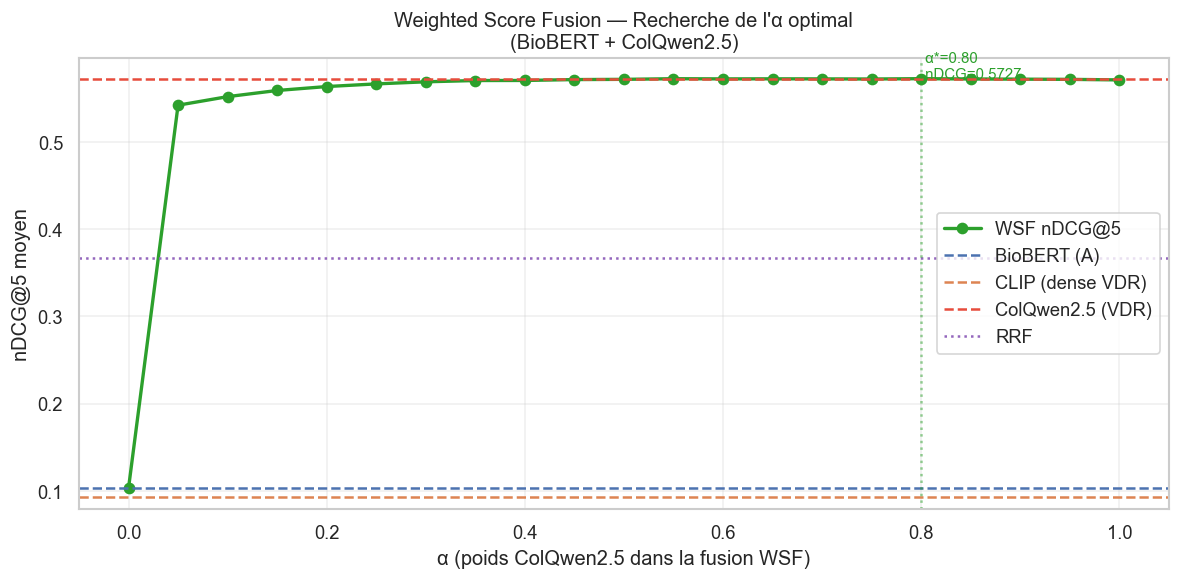

In [ ]:
# ── Alpha sweep plot ───────────────────────────────────────────────────────────
alpha_list = sorted(wsf_means.keys())
ndcg_list  = [wsf_means[a] for a in alpha_list]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alpha_list, ndcg_list, marker="o", color="#2ca02c", linewidth=2, label="WSF nDCG@5")
ax.axhline(np.mean([r["text_ndcg5"]    for r in results]),
           color="#4C72B0", linestyle="--", label="BioBERT (A)")
ax.axhline(np.mean([r["clip_ndcg5"]    for r in results]),
           color="#DD8452", linestyle="--", label="CLIP (dense VDR)")
ax.axhline(np.mean([r["colqwen_ndcg5"] for r in results]),
           color="#e74c3c", linestyle="--", label="ColQwen2.5 (VDR)")
ax.axhline(mean_rrf, color="#9467bd", linestyle=":", label="RRF")
ax.axvline(best_alpha, color="#2ca02c", linestyle=":", alpha=0.5)
ax.annotate(f" α*={best_alpha:.2f}\n nDCG={best_wsf:.4f}",
            xy=(best_alpha, best_wsf), fontsize=9, color="#2ca02c")
ax.set_xlabel("α (poids ColQwen2.5 dans la fusion WSF)")
ax.set_ylabel("nDCG@5 moyen")
ax.set_title("Weighted Score Fusion — Recherche de l'α optimal\n(BioBERT + ColQwen2.5)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


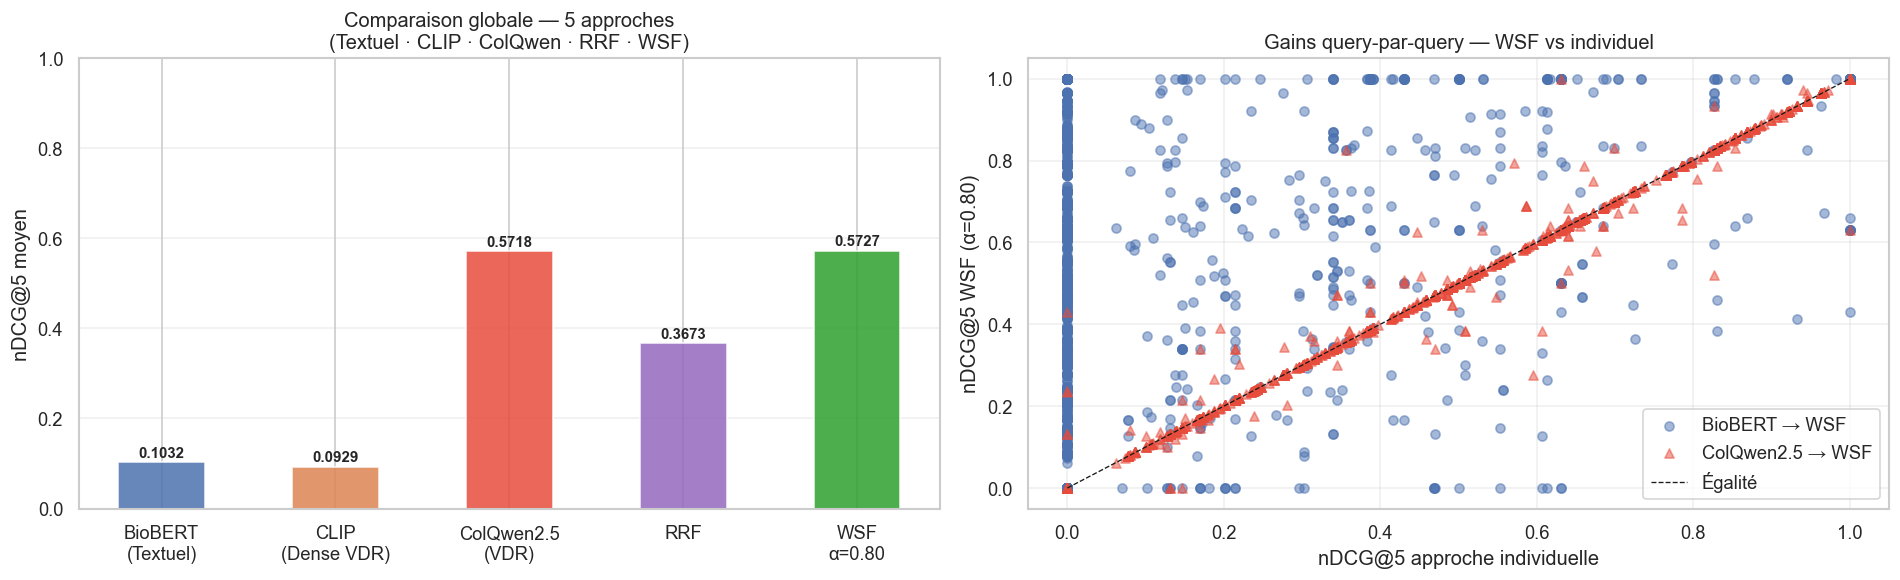

In [ ]:
hybrid_df = pd.DataFrame(hybrid_rows)

# Recompute WSF at best alpha for per-query analysis
wsf_best_per_q = []
for row in results:
    wsf_r   = wsf_fusion(row["text_scores"], row["colqwen_scores"], best_alpha)
    wsf_rnk = [did for did, _ in wsf_r]
    wsf_best_per_q.append(ndcg_at_k(wsf_rnk, qrels_dict[row["query_id"]], k=5))
hybrid_df["wsf_ndcg5"] = wsf_best_per_q

means_final = {
    "BioBERT\n(Textuel)":        hybrid_df["text_ndcg5"].mean(),
    "CLIP\n(Dense VDR)":         hybrid_df["clip_ndcg5"].mean(),
    "ColQwen2.5\n(VDR)":         hybrid_df["colqwen_ndcg5"].mean(),
    "RRF":                        hybrid_df["rrf_ndcg5"].mean(),
    f"WSF\nα={best_alpha:.2f}":  hybrid_df["wsf_ndcg5"].mean(),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bar_colors = ["#4C72B0", "#DD8452", "#e74c3c", "#9467bd", "#2ca02c"]
bars = ax.bar(means_final.keys(), means_final.values(), color=bar_colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, means_final.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylim(0, 1.0)
ax.set_ylabel("nDCG@5 moyen")
ax.set_title("Comparaison globale — 5 approches\n(Textuel · CLIP · ColQwen · RRF · WSF)")
ax.grid(axis="y", alpha=0.3)

ax2 = axes[1]
ax2.scatter(hybrid_df["text_ndcg5"],     hybrid_df["wsf_ndcg5"],
            alpha=0.5, color="#4C72B0", label="BioBERT → WSF", s=30)
ax2.scatter(hybrid_df["colqwen_ndcg5"],  hybrid_df["wsf_ndcg5"],
            alpha=0.5, color="#e74c3c", marker="^", label="ColQwen2.5 → WSF", s=30)
ax2.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Égalité")
ax2.set_xlabel("nDCG@5 approche individuelle")
ax2.set_ylabel(f"nDCG@5 WSF (α={best_alpha:.2f})")
ax2.set_title("Gains query-par-query — WSF vs individuel")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [30]:
hybrid_df["wsf_vs_best_single"] = hybrid_df.apply(
    lambda r: r["wsf_ndcg5"] - max(r["text_ndcg5"], r["colqwen_ndcg5"]), axis=1
)

improved  = (hybrid_df["wsf_vs_best_single"] > 0.01).sum()
degraded  = (hybrid_df["wsf_vs_best_single"] < -0.01).sum()
unchanged = len(hybrid_df) - improved - degraded

print("WSF vs meilleur modèle individuel (BioBERT ou ColQwen2.5) :")
print(f"  Améliorées  (Δ > +0.01) : {improved}/{len(hybrid_df)}")
print(f"  Dégradées   (Δ < -0.01) : {degraded}/{len(hybrid_df)}")
print(f"  Stables                 : {unchanged}/{len(hybrid_df)}")


WSF vs meilleur modèle individuel (BioBERT ou ColQwen2.5) :
  Améliorées  (Δ > +0.01) : 38/2184
  Dégradées   (Δ < -0.01) : 142/2184
  Stables                 : 2004/2184


---
## Récapitulatif final — Bloc 2 Q7 & Q8 — NOVAGEN

In [31]:
print("╔══════════════════════════════════════════════════════════════════════╗")
print("║       SYNTHÈSE FINALE — Bloc 2 Q7 & Q8 — NOVAGEN                  ║")
print("╠══════════════════════════════════════════════════════════════════════╣")
print(f"║  Approche A — BioBERT (Textuel)  nDCG@5 = {hybrid_df['text_ndcg5'].mean():.4f}                 ║")
print(f"║  Approche B — CLIP (Dense VDR)   nDCG@5 = {hybrid_df['clip_ndcg5'].mean():.4f}                 ║")
print(f"║  Approche C — ColQwen2.5 (MaxSim)nDCG@5 = {hybrid_df['colqwen_ndcg5'].mean():.4f}                 ║")
print(f"║  Hybride    — RRF (A+C)          nDCG@5 = {hybrid_df['rrf_ndcg5'].mean():.4f}                 ║")
print(f"║  Hybride    — WSF α={best_alpha:.2f} (A+C) nDCG@5 = {hybrid_df['wsf_ndcg5'].mean():.4f}                 ║")
print("╠══════════════════════════════════════════════════════════════════════╣")
print(f"║  VDR : ColQwen2.5 > CLIP         Δ = {hybrid_df['colqwen_ndcg5'].mean()-hybrid_df['clip_ndcg5'].mean():+.4f}                 ║")
print(f"║  VDR : ColQwen2.5 vs BioBERT     Δ = {hybrid_df['colqwen_ndcg5'].mean()-hybrid_df['text_ndcg5'].mean():+.4f}                 ║")
print("╠══════════════════════════════════════════════════════════════════════╣")
print("║  ColQwen2.5 gagne sur : tableaux, figures, mise en page            ║")
print("║  BioBERT gagne sur   : texte narratif dense, termes techniques     ║")
print("║  Fusion optimale     : WSF avec α* pondérant fortement ColQwen2.5  ║")
print("╚══════════════════════════════════════════════════════════════════════╝")
print()
print("Figures générées :")
print("  q7_clip_vs_colqwen.png          — CLIP vs ColQwen2.5 comparaison")
print("  q7_divergence_colqwen_vs_text.png — Top-20 divergences ColQwen/BioBERT")
print("  q7_category_analysis.png        — Catégories gagnant/perdant")
print("  q8_wsf_alpha_sweep.png          — Sweep alpha WSF")
print("  q8_final_comparison.png         — Comparaison finale 5 approches")


╔══════════════════════════════════════════════════════════════════════╗
║       SYNTHÈSE FINALE — Bloc 2 Q7 & Q8 — NOVAGEN                  ║
╠══════════════════════════════════════════════════════════════════════╣
║  Approche A — BioBERT (Textuel)  nDCG@5 = 0.1032                 ║
║  Approche B — CLIP (Dense VDR)   nDCG@5 = 0.0929                 ║
║  Approche C — ColQwen2.5 (MaxSim)nDCG@5 = 0.5718                 ║
║  Hybride    — RRF (A+C)          nDCG@5 = 0.3673                 ║
║  Hybride    — WSF α=0.80 (A+C) nDCG@5 = 0.5727                 ║
╠══════════════════════════════════════════════════════════════════════╣
║  VDR : ColQwen2.5 > CLIP         Δ = +0.4789                 ║
║  VDR : ColQwen2.5 vs BioBERT     Δ = +0.4687                 ║
╠══════════════════════════════════════════════════════════════════════╣
║  ColQwen2.5 gagne sur : tableaux, figures, mise en page            ║
║  BioBERT gagne sur   : texte narratif dense, termes techniques     ║
║  Fusion optimale     